# HW2P2: Image Recognition and Verification

> This is the second homework assignment for **11-785: Introduction to Deep Learning**, which focuses on the task of **image verification**. In this assignment, we first train a custom **convolutional neural network (CNN)** to perform **face classification** over **8,631 distinct identities**.
>
> Once the model is trained, we use it to extract **face embeddings** for images. These embeddings are then compared across pairs of images to determine whether the two faces belong to the **same identity** or **different identities**, thereby solving the image verification problem.


## 📅 Submission Schedule
- ✅ **Checkpoint:** Feburary 20, 2026 @ 11:59 PM (EST)  
- 🏁 **Final Submission:** Feburary 27, 2026 @ 11:59 PM (EST)  
  *Slack deadline: March 13, 2026 @ 11:59 PM (EST)*  
- 💻 **Code Submission:** 
  - Due: March 1st, 2026 @ 11:59PM (EST)
  - Closes: March 13, 2026 @ 11:59 PM (EST) *or day-of via Slack*

## Requirement Acknowledgement

Setting the flag below to **True** indicates that you have read, understood, and agree to comply with **all** of the following requirements:

1. **Slack Days Usage**  
   Slack days may be used **only** for the **P2 Final submission**, *not* for the checkpoint.  
   Specifically, slack days may be applied to submit **final P2 Kaggle scores** to the **Slack Kaggle Competition**, at the expense of your available slack days.

2. **Final Code Submission Deadline**  
   The final **Autolab code submission** is due **within 48 hours after** the Kaggle competition deadline,  
   or **on the same day** as your final Kaggle submission—whichever occurs first.

3. **Kaggle Username & Score Verification**  
   You must provide your **Kaggle username** below. We will use it to retrieve your official **PRIVATE leaderboard** score.  
   Minor score or output variance is acceptable; however, any discrepancies caused by **modifications to the required submission code**
   (including the notebook’s final submission cell) will result in an **Academic Integrity Violation (AIV)**.

4. **Model Implementation Restrictions**  
   You are **not permitted** to use pre-trained or pre-loaded models (e.g., from Hugging Face or similar libraries).  
   You **may** implement models described in research papers or articles, but they **must** be implemented **from scratch**
   using fundamental PyTorch components (e.g., `Linear`, `Conv2d`, etc.).

5. **Data Usage Restrictions**  
   The use of **any external data or datasets** is strictly prohibited at **any stage** of this assignment.

6. **Collaboration Policy**  
   You may collaborate with teammates to run experiments or ablations.  
   However, you must submit **your own code** and **your own results**.

7. **Academic Integrity**  
   Failure to comply with any of the above requirements will be treated as an **Academic Integrity Violation (AIV)**.

8. **Late Submissions**  
   Late submissions **must** be submitted through the **Slack Kaggle Competition** (see write-up for details).  
   Submissions made to the **regular Kaggle competition** after the original deadline will **not** be considered,
   regardless of remaining slack days.


In [5]:
# @title Click to acknowledge then run cell!
ACKNOWLEDGED = True # @param {"type":"boolean","placeholder":"False"}


## Welcome to the World of Convolutions!

In the previous homework, you explored **Multi-Layer Perceptrons (MLPs)**—the foundational building blocks of deep learning. You saw how MLPs can learn patterns from data, predict phonemes from speech, and even approximate complex functions. However, despite their expressive power, MLPs are not well-suited for image data. Flattening an image into a one-dimensional vector discards crucial **spatial information**, such as how neighboring pixels relate to one another.

This limitation motivates the use of **Convolutional Neural Networks (CNNs)**. CNNs preserve spatial structure by operating directly on image grids, allowing models to learn meaningful visual patterns. In doing so, they bring us closer to designing systems that can truly *see* and interpret the visual world.

In this homework, you will dive into CNNs through **face classification** and **face verification** tasks. In face classification, the goal is to identify a face as belonging to one of several known identities. In contrast, face verification asks a different question: *Do these two images belong to the same person?*—even if that person was never seen during training.

To make this concrete, imagine being given a photo of a friend and a group photo. A classifier would attempt to name your friend, while a verification model would simply determine whether the two images depict the same individual. CNNs enable this by learning **hierarchical features**: early layers capture edges and textures, while deeper layers encode higher-level concepts such as facial structures and distinctive features.

A key theme of this assignment is understanding how **loss functions** shape model behavior. Classification models typically rely on **Cross-Entropy Loss**, which encourages correct label prediction. Verification tasks, however, depend on learning meaningful **embeddings**, where similarity in feature space reflects identity similarity. Loss functions such as **Triplet Loss** or **ArcFace Loss** are designed for this purpose, pulling embeddings of the same person closer together while pushing different identities apart. A well-trained verification model can even distinguish between visually similar individuals—such as siblings—while remaining robust to changes in pose, lighting, or expression.

Beyond theory, this homework emphasizes **practical deep learning skills**. You will preprocess image data, apply data augmentation techniques (e.g., random cropping or flipping), and experiment with modern CNN architectures such as **ResNet** or **ConvNeXt**. Along the way, you will discover that a model optimized for classification is not automatically suitable for verification—highlighting the importance of aligning architectural choices and loss functions with the task at hand.

By the end of this assignment, you will have built a robust face recognition system inspired by real-world applications, from smartphone unlocking to identity verification systems. Let’s get started.

# **SET-UP**


Click [**HERE**](https://www.kaggle.com/t/12ca057eb27d4c62ae093a0f407e0651) to join the competition first!

## **Colab Users**
Follow the steps below to set up your Google Colab environment.

### Step 1: Verify GPU
Check that a GPU is available:

In [ ]:
!nvidia-smi

### Step 2: Install Required Packages

In [ ]:
!pip install wandb==0.23.1 pytorch_metric_learning torchinfo kaggle==1.8.0 --quiet

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [ ]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "<your-username>" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "<your-key>" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

### Step 4: Download Dataset

In [ ]:
api.competition_download_files('11785-hw-2-p-2-face-verification-spring-2026')
!unzip -qo /content/11785-hw-2-p-2-face-verification-spring-2026.zip -d /content/dataset
!rm -rf /content/11785-hw-2-p-2-face-verification-spring-2026.zip

In [ ]:
!du -h --max-depth=2 /content/dataset/hw2p2_data

## **Kaggle Users**



### Step 1: Environment Setup

In [2]:
!pip install wandb==0.23.1 pytorch_metric_learning torchinfo kaggle==1.8.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.9/22.9 MB 54.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 68.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 11.4 MB/s eta 0:00:00


### Step 2: Get Data

If you are using Kaggle, follow these steps to add the dataset directly to your notebook:
1. Join the kaggle competition (https://www.kaggle.com/t/12ca057eb27d4c62ae093a0f407e0651)
2. Open your **Kaggle Notebook**.  
3. Navigate to **Notebook → Input**.  
4. Click **Add Input**.  
5. Choose "Competition Datasets" and "Your work", and then you'll be able to see the competiation "11785-hw-2-p-2-face-verification-spring-2026"
6. Click the **➕ (plus sign)** to add the dataset to your notebook.  

### Step 3: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [ ]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd       2392           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured   1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured   1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured   1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detec

## **PSC Users**

### Step 1: Setting Up Your Environment on Bridges2

❗️⚠️ For this homework, we are **providing a shared Conda environment** for the entire class. Therefore, PSC users **do not need to manually install any packages**.

❗️⚠️ For this homework, you need to **download the dataset to the node `$LOCAL`** to avoid I/O bottlenecks from the shared filesystem. This means that each time you run on a new node, you need to download the dataset again. However, as long as you stay on the same node, you do not need to re-download the dataset. Please refer to **Step 3** for the detailed procedure.

Follow these steps to set up the environment and start a Jupyter notebook on Bridges2:

- To run your notebook more efficiently on PSC, we need to use a **Jupyter Server** hosted on a compute node.

- You can use your prefered way of connecting to the Jupyter Server.  **The recommended way is to connect in VSCode.**
Follow the instructions below.



#### **Connect in VSCode**
SSH into Bridges2 and navigate to your **Jet directory** (`Jet/home/<your_psc_username>`). Upload your notebook there, and then connect to the Jupyter Server from that directory.

#### **1.1 SSH into Bridges2**
1）Open VS Code and click on the `Extensions` icon in the left sidebar. Make sure the "**Remote - SSH**" extension is installed.

2）Open the command palette (**Shift+Command+P** on Mac, **Ctrl+Shift+P** on Windows). A search box will appear at the top center. Choose `"Remote-SSH: Add New SSH Host"`, then enter:

```bash
ssh <your_username>@bridges2.psc.edu #change <your_username> to your username
```

Next, choose `"/Users/<your_username>/.ssh/config"` as the config file. A dialog will appear in the bottom right saying "Host Added". Click `"Connect"`, and then enter your password.

(Note: After adding the host once, you can later use `"Remote-SSH: Connect to Host"` and select "bridges2.psc.edu" from the list.)

3）Once connected, click `"Explorer"` in the left sidebar > "Open Folder", and navigate to your home directory under the project grant:
```bash
/jet/home/<your_username>  #change <your_username> to your username
```

4）You can now drag your notebook files directly into the right-hand pane (your remote home directory), or upload them using `scp` into your folder.

> ❗️⚠️ The following steps should be executed in the **VSCode integrated terminal**.

#### **1.2 Navigate to Your Directory**
Make sure to use this `/jet/home/<your_username>` as your working directory, since all subsequent operations (up to submission) are based on this path.
```bash
cd /jet/home/<your_username>  #change <your_username> to your username
```

#### **1.3 Request a Compute Node**
```bash
interact -p GPU-shared --gres=gpu:v100-32:1 -t 8:00:00 -A cis250019p
```

#### **1.4 Load the Anaconda Module**
```bash
module load anaconda3
```

#### **1.5 Activate the provided HW Environment**
```bash
conda deactivate # First, deactivate any existing Conda environment
conda activate /ocean/projects/cis250019p/mzhang23/TA/envs/IDLS26 && export PYTHONNOUSERSITE=1
```

#### **1.6 Start Jupyter Notebook**
Launch Jupyter Notebook:
```bash
jupyter notebook --no-browser --ip=0.0.0.0
```

Go to **Kernel** → **Select Another Kernel** → **Existing Jupyter Server**
   Enter the URL of the Jupyter Server:```http://{hostname}:{port}/tree?token={token}```
   
   *(Usually, this URL appears in the terminal output after you run `jupyter notebook --no-browser --ip=0.0.0.0`, in a line like:  “Jupyter Server is running at: http://...”)*

   - eg: `http://v011.ib.bridges2.psc.edu:8888/tree?token=e4b302434e68990f28bc2b4ae8d216eb87eecb7090526249`

> **Note**: Replace `{hostname}`, `{port}` and `{token}` with your actual values from the Jupyter output.

After launching the Jupyter notebook, you can run the cells directly inside the notebook — no need to use the terminal for the remaining steps.

#### **1.7 Navigate to Your Jet Directory**

After launching the Jupyter notebook, you can run the cells directly inside the notebook — no need to use the terminal for the remaining steps.

First, navigate to your **Jet directory** (`/jet/home/<your_username>`).

️❗️⚠ Please make sure to use your **Jet directory**, not the **Ocean path** — **all HW setup and outputs below are based on this directory**.

In [6]:
# Make sure you are in your directory
!pwd #should be /jet/home/<your_username>, if not, uncomment the following line and replace with your actual username:
%cd /jet/home/sdabir
#TODO: replace the "<your_username>" to yours

/jet/home/sdabir
/jet/home/sdabir


### Step 2: Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [ ]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] =""# TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import
api.competitions_list_cli()

ref                                                                              deadline             category          reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  ---------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured   2,207,152 Usd       2737           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured   1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured   1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured   1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detec

### Step 3: Get Data

❗️⚠️ In this homework, you need to download the dataset to the **GPU node’s local storage (`$LOCAL`)** instead of using the shared /ocean directory, in order to avoid I/O bottlenecks. Using the shared filesystem may slow down training drastically and can take hours per epoch.

Note that **the local storage on a compute node is temporary and will be cleared** when your node time limit is reached or when you move to a different node. Therefore, **every time you run on a new node, you need to re-run the dataset download step**. However, as long as you stay on the same node, you do NOT need to download the dataset again.

Join the HW2P2 kaggle competition (https://www.kaggle.com/t/12ca057eb27d4c62ae093a0f407e0651)

In [8]:
api.competition_download_files('11785-hw-2-p-2-face-verification-spring-2026', path=os.environ["LOCAL"])
!mkdir -p $LOCAL/dataset
!unzip -qo $LOCAL/11785-hw-2-p-2-face-verification-spring-2026.zip -d $LOCAL/dataset
!rm -f $LOCAL/11785-hw-2-p-2-face-verification-spring-2026.zip

You can run the following block to explore the shared directory structure:

(Note: You do **NOT** need to change any `data_path` in the code below. Each time you start on a new node, as long as you run the dataset download block above, your dataset will always be located at:`/local/dataset/hw2p2_data`. This path will not change even if you are assigned to a different node.)

In [9]:
import os
data_path = "/local/dataset/hw2p2_data" # this is the path of the dataset on your node
print("Files in shared hw2p2 dataset:", os.listdir(data_path))

Files in shared hw2p2 dataset: ['cls_data', 'test_pairs.txt', 'val_pairs.txt', 'ver_data']


In [10]:
!apt-get install tree
!tree -L 2 /local/dataset/hw2p2_data

/bin/bash: apt-get: command not found


/local/dataset/hw2p2_data
├── cls_data
│   ├── dev
│   ├── test
│   └── train
├── test_pairs.txt
├── val_pairs.txt
└── ver_data
    ├── 005DnBCJ.jpg
    ├── 00ogqjIH.jpg
    ├── 00pTd1LL.jpg
    ├── 00uA3rkT.jpg
    ├── 01KH7cQa.jpg
    ├── 01nMCEYR.jpg
    ├── 03h9MqyM.jpg
    ├── 03sCtQd8.jpg
    ├── 03sEX4qL.jpg
    ├── 04cWxoVk.jpg
    ├── 04hJfKua.jpg
    ├── 04hkvIkq.jpg
    ├── 04HnG3HS.jpg
    ├── 04itghbq.jpg
    ├── 05Oqs7sR.jpg
    ├── 05SA7lN1.jpg
    ├── 05UA2hN4.jpg
    ├── 06I4upb5.jpg
    ├── 07vkSSaz.jpg
    ├── 081qR6Mi.jpg
    ├── 08AWeln9.jpg
    ├── 08bNx4K6.jpg
    ├── 08ZzGzMT.jpg
    ├── 09DpuPF4.jpg
    ├── 09mZeVCC.jpg
    ├── 0a8K4uf6.jpg
    ├── 0AajSril.jpg
    ├── 0ANWFR9b.jpg
    ├── 0AojVMuw.jpg
    ├── 0aXSD61G.jpg
    ├── 0AYuB4ja.jpg
    ├── 0B2STCtu.jpg
    ├── 0BCgHN64.jpg
    ├── 0bCoVV4N.jpg
    ├── 0BG18517.jpg
    ├── 0bK5phL0.jpg
    ├── 0BqYMoFI.jpg
    ├── 0Brk2iZB.jpg
    ├── 0BUgmAqz.jpg
    ├── 0bXqRBHB.jpg
    ├── 0bz4nZLw.jpg
    ├── 0CB

# Imports

In [41]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import torchvision
from torchvision.io import decode_image
from torchvision.utils import make_grid
from torchvision import transforms
import torchvision.transforms.v2 as T
import os
import gc
from tqdm import tqdm
from tqdm.auto import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn import metrics as mt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import glob
import wandb
import matplotlib.pyplot as plt
from pytorch_metric_learning import samplers
import csv
import pandas as pd
from torchinfo import summary
from collections import OrderedDict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", DEVICE)


Device:  cuda


In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")
KAGGLE_USERNAME = os.environ.get("KAGGLE_USERNAME", "")
KAGGLE_API_KEY = os.environ.get("KAGGLE_KEY", "")

# Config

### ⚠️ `Note`

- You will need to set the root path to your `hw2p2_data` folder in `data: root:`. This will depend on your setup. For eg. if you are following out setup instruction:
  - `Colab:`: `"/content/dataset/hw2p2_data"`
  - `Kaggle:`: `"/kaggle/input/11785-hw-2-p-2-face-verification-spring-2026/hw2p2_data"`
  - `PSC`: `"/local/dataset/hw2p2_data"`

Kindly modify your configurations to suit your ablations and be keen to include your name.

In [12]:
config = {
    'data_root': "/local/dataset/hw2p2_data", # TODO: Add your data root
    'batch_size': 128, # Increase this if your GPU can handle it
    'lr': 0.1,
    'epochs': 25, # 20 epochs is recommended ONLY for the early submission - you will have to train for much longer typically.
    'num_classes': 8631, # Dataset contains 8631 classes for classification, reduce this number if you want to train on a subset, but only for train dataset and not on val dataset
    'embedding_size': 512,
    'checkpoint_dir': "/local/dataset/hw2p2_data", #TODO: Checkpoint directory
    'augument': True
    # Include other parameters as needed.
}

# Data Augumentations

In [13]:
def create_transforms(image_size: int = 112, augment: bool = True) -> T.Compose:
    """Create transform pipeline for face recognition."""

    # Step 1: Basic transformations
    transform_list = [
        # Resize the image to the desired size (image_size x image_size)
        T.Resize((image_size, image_size)),

        # Convert PIL Image to tensor
        T.ToImage(),

        # Convert image to float32 and scale the pixel values to [0, 1]
        T.ToDtype(torch.float32, scale=True),
    ]

    # Step 2: Data augmentation (optional, based on `augment` argument)
    if augment:  # This block will be executed if `augment=True`
        # TODO: Add transformations for data augmentation (e.g., random horizontal flip, rotation, etc.)
        # HINT: What transforms help faces look more varied?
        # Think: Does a horizontally flipped face still look like the same person?
        # What about small rotations or color changes?
        # Example:
        transform_list.extend([
            # Add your augmentations here
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomRotation(degrees=10),
            T.RandomErasing(p=0.1, scale=(0.02, 0.1)) # Acts as a strong regularizer
        ])

    # Step 3: Standard normalization for image recognition tasks
    # The Normalize transformation requires mean and std values for each channel (R, G, B).
    # Here, we are normalizing the pixel values to have a mean of 0.5 and std of 0.5 for each channel.
    transform_list.extend([
        T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Standard mean and std for face recognition tasks
    ])

    # Return the composed transformation pipeline
    return T.Compose(transform_list)


In [14]:
train_transforms = create_transforms(augment=config['augument'])
val_transforms   = create_transforms(augment=False)

# Datasets and DataLoaders

## Classification Datasets and Dataloaders

In [15]:
class ImageDataset(Dataset):
    """Custom dataset for loading images with optional labels."""

    def __init__(self, root, transform, num_classes=None, preload=False):
        """
        Args:
            root (str): Dataset root directory.
                Expected structure:
                  - labeled:
                        root/
                          images/
                          labels.txt   (img label)
                  - unlabeled:
                        root/
                          images/
            transform (callable): Transform applied to images.
            num_classes (int, optional): Number of classes to keep (labeled only).
            preload (bool): Preload images into memory.
        """
        self.root = root
        self.transform = transform
        self.preload = preload

        self.image_paths = []
        self.labels = None      # None → unlabeled dataset
        self.classes = None
        self.images = []

        labels_file = os.path.join(self.root, "labels.txt")
        images_dir = os.path.join(self.root, "images")

        # --------------------------------------------------
        # Detect labeled vs unlabeled dataset
        # --------------------------------------------------
        has_labels = os.path.exists(labels_file)

        if has_labels:
            self.labels = []
            self.classes = set()

            with open(labels_file, "r") as f:
                lines = f.readlines()

            # Sort by label (keeps your original behavior)
            lines = sorted(lines, key=lambda x: int(x.strip().split(" ")[-1]))

            all_labels = sorted(set(int(line.strip().split(" ")[1]) for line in lines))

            if num_classes is not None:
                selected_classes = set(all_labels[:num_classes])
            else:
                selected_classes = set(all_labels)

            for line in tqdm(lines, desc="Loading labeled dataset"):
                img_path, label = line.strip().split(" ")
                label = int(label)

                if label in selected_classes:
                    self.image_paths.append(os.path.join(images_dir, img_path))
                    self.labels.append(label)
                    self.classes.add(label)

            self.classes = sorted(self.classes)

            assert len(self.image_paths) == len(self.labels), "Images and labels mismatch!"

        else:
            # --------------------------------------------------
            # Unlabeled dataset: load all images from images/
            # --------------------------------------------------
            image_files = sorted(os.listdir(images_dir))

            for img in tqdm(image_files, desc="Loading unlabeled dataset"):
                self.image_paths.append(os.path.join(images_dir, img))

        # --------------------------------------------------
        # Preload images if requested
        # --------------------------------------------------
        if self.preload:
            self.images = [
                decode_image(p, mode="RGB") / 255.0
                for p in tqdm(self.image_paths, desc="Preloading images")
            ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if self.preload:
            image = self.images[idx]
        else:
            image = decode_image(self.image_paths[idx], mode="RGB") / 255.0

        image = self.transform(image)

        # Return with or without label
        if self.labels is not None:
            return image, self.labels[idx]
        else:
            return image


In [16]:
gc.collect
cls_data_dir = config['data_root'] + '/cls_data'

# Datasets
# TODO: Implement the datasets for training, validation, and testing
cls_train_dataset = ImageDataset(
    root=os.path.join(cls_data_dir, 'train'),
    transform=train_transforms,
    num_classes=config['num_classes']
)
cls_val_dataset = ImageDataset(
    root=os.path.join(cls_data_dir, 'dev'),
    transform=val_transforms
)
cls_test_dataset = ImageDataset(
    root=os.path.join(cls_data_dir, 'test'),
    transform=val_transforms
)

assert cls_train_dataset.classes == cls_val_dataset.classes == cls_test_dataset.classes, "Class mismatch!"

# Dataloaders
# TODO: Implement the dataloaders for training, validation, and testing
cls_train_loader = DataLoader(
    cls_train_dataset, 
    batch_size=config['batch_size'], 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

# 2. Val Loader: Shuffle=False (order doesn't matter, but consistent is better)
cls_val_loader = DataLoader(
    cls_val_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

# 3. Test Loader: Shuffle=False is CRITICAL for Kaggle submission (order must match IDs)
cls_test_loader = DataLoader(
    cls_test_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

Loading labeled dataset:   0%|          | 0/431550 [00:00<?, ?it/s]

Loading labeled dataset:   0%|          | 0/43155 [00:00<?, ?it/s]

Loading labeled dataset:   0%|          | 0/43155 [00:00<?, ?it/s]

## Verification Dataset and Datatloaders

In [17]:
class ImagePairDataset(Dataset):
    """Custom dataset for loading and transforming image pairs (labeled or unlabeled)."""

    def __init__(self, root, pairs_file, transform, preload=False):
        """
        Args:
            root (str): Path to the directory containing the images.
            pairs_file (str): File with:
                - img1 img2 label   (labeled)
                - img1 img2         (unlabeled)
            transform (callable): Transform to apply to images.
            preload (bool): Whether to preload images into memory.
        """
        self.root = root
        self.transform = transform
        self.preload = preload

        self.image1_paths = []
        self.image2_paths = []
        self.matches = None  # None → unlabeled dataset

        # Read file
        with open(pairs_file, "r") as f:
            lines = f.readlines()

        # Detect whether labels exist
        first_cols = lines[0].strip().split()
        has_labels = len(first_cols) == 3

        if has_labels:
            self.matches = []

        for line in tqdm(lines, desc="Loading dataset"):
            parts = line.strip().split()

            if has_labels:
                img1, img2, match = parts
                self.matches.append(int(match))
            else:
                img1, img2 = parts

            self.image1_paths.append(os.path.join(self.root, img1))
            self.image2_paths.append(os.path.join(self.root, img2))

        assert len(self.image1_paths) == len(self.image2_paths)
        if has_labels:
            assert len(self.matches) == len(self.image1_paths)

        # Preload images if requested
        if self.preload:
            self.image1_cache = [
                decode_image(p, mode="RGB") / 255.0
                for p in tqdm(self.image1_paths, desc="Preloading image1")
            ]
            self.image2_cache = [
                decode_image(p, mode="RGB") / 255.0
                for p in tqdm(self.image2_paths, desc="Preloading image2")
            ]

    def __len__(self):
        return len(self.image1_paths)

    def __getitem__(self, idx):
        # Load images
        if self.preload:
            img1 = self.image1_cache[idx]
            img2 = self.image2_cache[idx]
        else:
            img1 = decode_image(self.image1_paths[idx], mode="RGB") / 255.0
            img2 = decode_image(self.image2_paths[idx], mode="RGB") / 255.0

        img1 = self.transform(img1)
        img2 = self.transform(img2)

        # Return with or without label
        if self.matches is not None:
            return img1, img2, self.matches[idx]
        else:
            return img1, img2


In [18]:
gc.collect()
base_path = config['data_root']
ver_data_dir = os.path.join(config['data_root'], 'ver_data')

# Datasets
# TODO: Implement the datasets for validation and testing
ver_val_dataset = ImagePairDataset(
    root=ver_data_dir,
    pairs_file=os.path.join(base_path, 'val_pairs.txt'),
    transform=val_transforms
)

# 2. Test Dataset
ver_test_dataset = ImagePairDataset(
    root=ver_data_dir,
    pairs_file=os.path.join(base_path, 'test_pairs.txt'),
    transform=val_transforms
)

# Dataloader
# TODO: Implement the dataloaders for validation and testing
ver_val_loader = DataLoader(
    ver_val_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

# 2. Test Loader: Shuffle must be False to match Kaggle IDs
ver_test_loader = DataLoader(
    ver_test_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

Loading dataset:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading dataset:   0%|          | 0/5000 [00:00<?, ?it/s]

# EDA and Viz

In [19]:
# Double-check your dataset/dataloaders work as expected

print("Number of classes    : ", len(cls_train_dataset.classes))
print("No. of train images  : ", cls_train_dataset.__len__())
print("Shape of image       : ", cls_train_dataset[0][0].shape)
print("Batch size           : ", config['batch_size'])
print("Train batches        : ", cls_train_loader.__len__())
print("Val batches          : ", cls_val_loader.__len__())

# Feel free to print more things if needed

Number of classes    :  8631
No. of train images  :  431550
Shape of image       :  torch.Size([3, 112, 112])
Batch size           :  128
Train batches        :  3372
Val batches          :  338


### Classification Dataset Viz

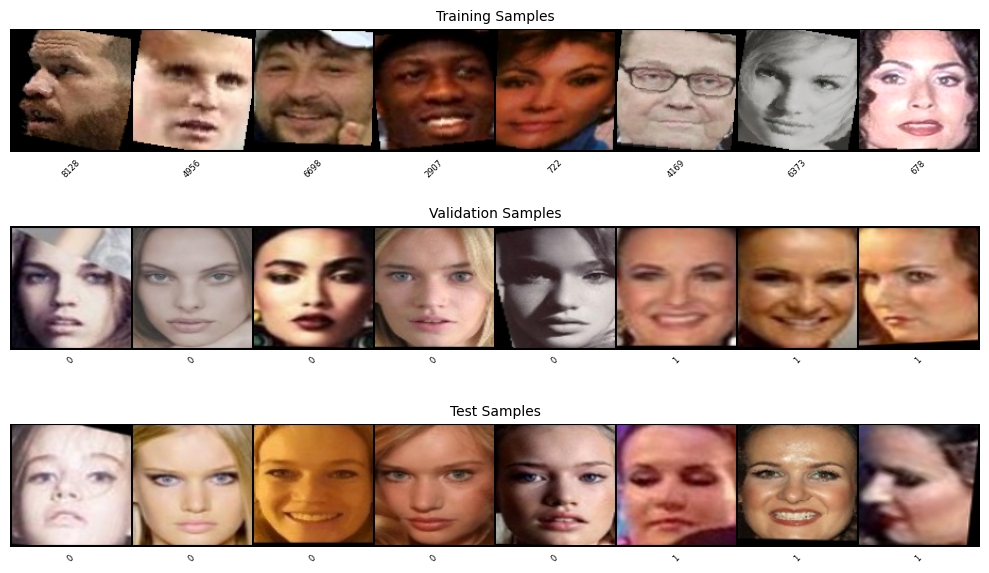

In [20]:
def show_cls_dataset_samples(train_loader, val_loader, test_loader, samples_per_set=8, figsize=(10, 6)):
    """
    Display samples from train, validation, and test datasets side by side

    Args:
        train_loader: Training data loader
        val_loader: Validation data loader
        test_loader: Test data loader
        samples_per_set: Number of samples to show from each dataset
        figsize: Figure size (width, height)
    """
    def denormalize(x):
        """Denormalize images from [-1, 1] to [0, 1]"""
        return x * 0.5 + 0.5

    def get_samples(loader, n):
        """Get n samples from a dataloader"""
        batch = next(iter(loader))
        return batch[0][:n], batch[1][:n]

    # Get samples from each dataset
    train_imgs, train_labels = get_samples(train_loader, samples_per_set)
    val_imgs, val_labels = get_samples(val_loader, samples_per_set)
    test_imgs, test_labels = get_samples(test_loader, samples_per_set)

    # Create figure
    fig, axes = plt.subplots(3, 1, figsize=figsize)

    # Plot each dataset
    for idx, (imgs, labels, title) in enumerate([
        (train_imgs, train_labels, 'Training Samples'),
        (val_imgs, val_labels, 'Validation Samples'),
        (test_imgs, test_labels, 'Test Samples')
    ]):

        # Create grid of images
        grid = make_grid(denormalize(imgs), nrow=8, padding=2)

        # Display grid
        axes[idx].imshow(grid.permute(1, 2, 0).cpu())
        axes[idx].axis('off')
        axes[idx].set_title(title, fontsize=10)

        # Add class labels below images (with smaller font)
        grid_width = grid.shape[2]
        imgs_per_row = min(8, samples_per_set)
        img_width = grid_width // imgs_per_row

        for i, label in enumerate(labels):
            col = i % imgs_per_row  # Calculate column position
            if label<len(train_loader.dataset.classes):
              class_name = train_loader.dataset.classes[label]
            else:
              class_name = f"Class {label} (Unknown)"
            axes[idx].text(col * img_width + img_width/2,
                         grid.shape[1] + 5,
                         class_name,
                         ha='center',
                         va='top',
                         fontsize=6,
                         rotation=45)

    plt.tight_layout()
    plt.show()

show_cls_dataset_samples(cls_train_loader, cls_val_loader, cls_test_loader)

### Ver Dataset Viz

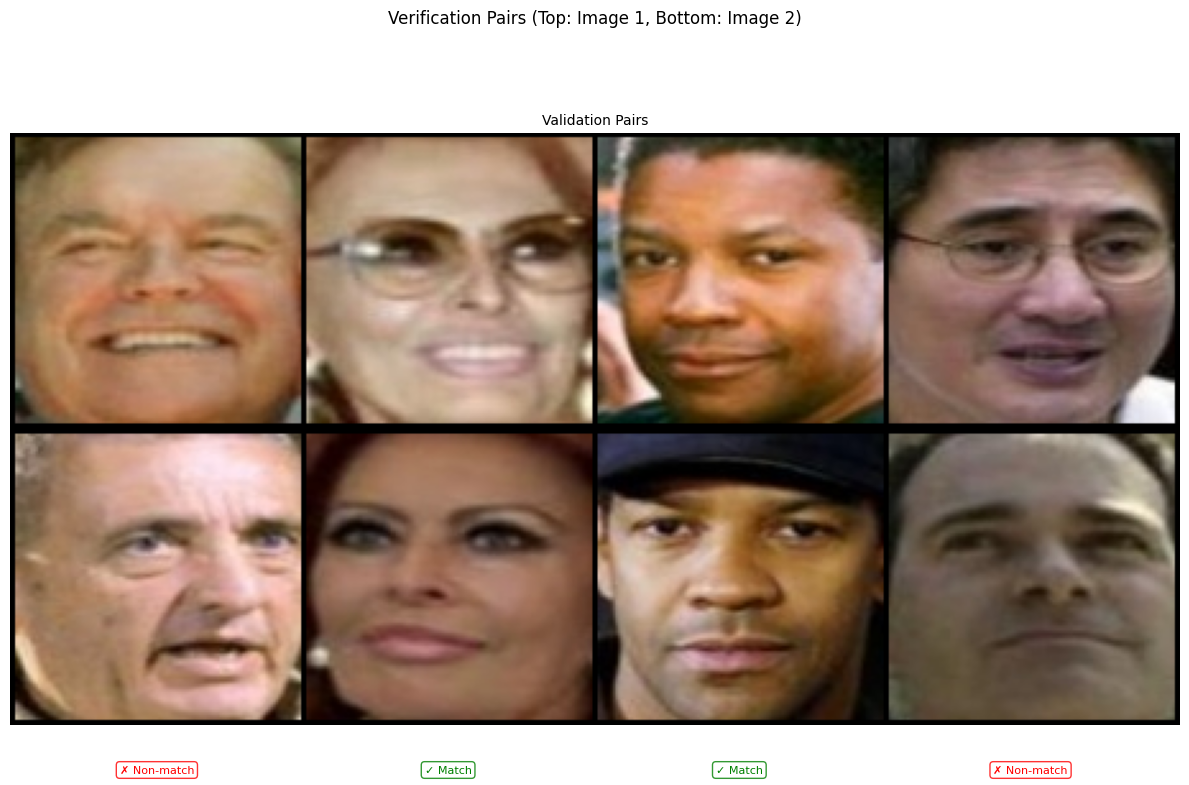

In [21]:
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid

def show_ver_dataset_samples(val_loader, samples_per_set=4, figsize=(12, 8)):
    """
    Display verification pairs from the validation dataset

    Args:
        val_loader: Validation data loader
        samples_per_set: Number of pairs to show from the dataset
        figsize: Figure size (width, height)
    """
    def denormalize(x):
        """Denormalize images from [-1, 1] to [0, 1]"""
        return x * 0.5 + 0.5

    def get_samples(loader, n):
        """Get n samples from a dataloader"""
        batch = next(iter(loader))
        return batch[0][:n], batch[1][:n], batch[2][:n]

    # Get samples from the validation dataset
    val_imgs1, val_imgs2, val_labels = get_samples(val_loader, samples_per_set)

    # Create figure and axis
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Create grids for both images in each pair
    grid1 = make_grid(denormalize(val_imgs1), nrow=samples_per_set, padding=2)
    grid2 = make_grid(denormalize(val_imgs2), nrow=samples_per_set, padding=2)

    # Combine the grids vertically
    combined_grid = torch.cat([grid1, grid2], dim=1)

    # Display the combined grid
    ax.imshow(combined_grid.permute(1, 2, 0).cpu())
    ax.axis('off')
    ax.set_title('Validation Pairs', fontsize=10)

    # Determine dimensions for placing the labels
    grid_width = grid1.shape[2]
    img_width = grid_width // samples_per_set

    # Add match/non-match labels for each pair
    for i, label in enumerate(val_labels):
        match_text = "✓ Match" if label == 1 else "✗ Non-match"
        color = 'green' if label == 1 else 'red'

        # Define a background box for the label
        bbox_props = dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec=color,
            alpha=0.8
        )

        ax.text(i * img_width + img_width / 2,
                combined_grid.shape[1] + 15,  # Position below the images
                match_text,
                ha='center',
                va='top',
                fontsize=8,
                color=color,
                bbox=bbox_props)

    plt.suptitle("Verification Pairs (Top: Image 1, Bottom: Image 2)", y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.05)
    plt.show()

show_ver_dataset_samples(ver_val_loader)


# Model Architecture

## FAQ

### **What is the “very low early-deadline architecture” (mandatory early submission)?**

The *very low early-deadline architecture* is a simple **5-layer convolutional neural network (CNN)** designed to meet the early-submission requirements. Remember that the **maximum parameter budget for this homework is 30 million parameters**.

**Architecture details:**

* The network consists of **5 convolutional layers**.
* The **first convolutional layer**:

  * Output channels: **64**
  * Kernel size: **7**
  * Stride: **4**
* The **next four convolutional layers** have:

  * Output channels: **128 → 256 → 512 → 1024**
  * Kernel size: **3**
  * Stride: **2**
* Each convolutional layer is followed by:

  * **Batch Normalization**
  * **ReLU activation**

For creating convolutional layers, refer to the PyTorch documentation:
[https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)

**Strided convolutions and padding:**

* Recall from lecture that a strided convolution can be viewed as a stride-1 convolution followed by downsampling.
* To preserve spatial alignment when using strided convolutions, choose:

  ```
  padding = kernel_size // 2
  ```
* Think about *why* this works: symmetric padding ensures the convolution remains centered over the input.

**Final pooling and flattening:**

* After the convolutional layers, apply **Adaptive Average Pooling** to reduce the spatial dimensions to **1 × 1**:

  * Use `AdaptiveAvgPool2d((1, 1))`
  * Documentation: [https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html](https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html)
* Finally, remove the trivial spatial dimensions (e.g., using `Flatten`).

For more layer options, see:
[https://pytorch.org/docs/stable/nn.html](https://pytorch.org/docs/stable/nn.html)

---

### **Why does this simple network use multiple downsampling convolutions?**

The input images are **112 × 112**. Each convolutional layer performs spatial downsampling.

* Downsampling by **2×** effectively **doubles the receptive field**, allowing neurons to capture information from a larger region of the image.
* Downsampling by **32×** in total is standard in many modern image models and provides a good balance between spatial resolution and semantic abstraction.

---

### **Why does this simple network use large channel sizes?**

Each time the spatial resolution is downsampled by **2×**, the computational cost drops by **4×** (assuming the number of channels stays constant).

To compensate:

* The number of channels is increased by **2×**, which increases computation by **4×**
* This keeps the overall computation roughly balanced across layers

Another intuition:

* As spatial resolution decreases, some spatial information is lost
* Increasing the number of channels helps preserve this information in the **feature (channel) dimension**

---


In [22]:
class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, self.expansion * out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class Network(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.in_channels = 64
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # ResNet-50 blocks
        self.layer1 = self._make_layer(Bottleneck, 64, 3, stride=1)
        self.layer2 = self._make_layer(Bottleneck, 128, 4, stride=2)
        self.layer3 = self._make_layer(Bottleneck, 256, 6, stride=2)
        self.layer4 = self._make_layer(Bottleneck, 512, 3, stride=2)
        
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        
        self.embedding_layer = nn.Linear(512 * Bottleneck.expansion, 512)
        self.embedding_bn = nn.BatchNorm1d(512)
        
        # We KEEP the linear layer for Phase 1 (CE Training)
        self.cls_layer = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x, return_feats: bool = False):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.pooling(out)
        out = self.flatten(out)
        
        feats = self.embedding_bn(self.embedding_layer(out))
        logits = self.cls_layer(feats)
        
        if return_feats:
            return feats
        return {"feats": feats, "out": logits}

# Initialize the model
model = Network(num_classes=config["num_classes"]).to(DEVICE)

#  model summary
summary(model, input_size=(2, 3, 112, 112))

Layer (type:depth-idx)                   Output Shape              Param #
Network                                  [2, 8631]                 --
├─Sequential: 1-1                        [2, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [2, 64, 112, 112]         1,728
│    └─BatchNorm2d: 2-2                  [2, 64, 112, 112]         128
│    └─ReLU: 2-3                         [2, 64, 112, 112]         --
├─Sequential: 1-2                        [2, 256, 112, 112]        --
│    └─Bottleneck: 2-4                   [2, 256, 112, 112]        --
│    │    └─Conv2d: 3-1                  [2, 64, 112, 112]         4,096
│    │    └─BatchNorm2d: 3-2             [2, 64, 112, 112]         128
│    │    └─Conv2d: 3-3                  [2, 64, 112, 112]         36,864
│    │    └─BatchNorm2d: 3-4             [2, 64, 112, 112]         128
│    │    └─Conv2d: 3-5                  [2, 256, 112, 112]        16,384
│    │    └─BatchNorm2d: 3-6             [2, 256, 112, 112]        5

In [23]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 28,978,167
Trainable Parameters: 28,978,167


# Loss | Optimizer | Scheduler

In [24]:
# ---------------------------------------------------
# Loss Function
# ---------------------------------------------------


# TODO: Initialize the criterion properly

# CE Loss
criterion = nn.CrossEntropyLoss().to(DEVICE)



# ---------------------------------------------------
# Optimizer
# ---------------------------------------------------

# SGD with momentum is a strong baseline for CNN training.
# Weight decay provides L2 regularization and helps prevent overfitting.

# TODO: Initialize the optimizer properly
# High learning rate (0.1)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config['lr'], 
    momentum=0.9, 
    weight_decay=5e-4
)

# ---------------------------------------------------
# Learning Rate Scheduler
# ---------------------------------------------------

# Cosine annealing smoothly decays the learning rate to zero over training.
# TODO: Initialize the scheduler properly
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])

# ---------------------------------------------------
# Mixed-Precision Training (FP16)
# ---------------------------------------------------

# GradScaler enables stable mixed-precision training on supported GPUs (e.g., T4, V100).
# This reduces memory usage and can significantly speed up training.
scaler = torch.amp.GradScaler(device='cuda')

# Metrics

In [25]:
class AverageMeter:
    """
    Tracks and computes the running average of a scalar metric.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0.0
        self.avg = 0.0
        self.sum = 0.0
        self.count = 0

    def update(self, val, n: int = 1):
        self.val = float(val)
        self.sum += val * n
        self.count += n
        self.avg = self.sum / max(self.count, 1)


def topk_accuracy(logits: torch.Tensor, targets: torch.Tensor, topk=(1,)):
    """
    Computes top-k accuracy for the given logits and targets.

    Args:
        logits (Tensor): Model outputs of shape (B, C)
        targets (Tensor): Ground-truth labels of shape (B,)
        topk (tuple): Values of k for top-k accuracy

    Returns:
        List[Tensor]: Accuracy values in percentage for each k
    """
    maxk = min(max(topk), logits.size(1))
    batch_size = targets.size(0)

    _, preds = logits.topk(maxk, dim=1, largest=True, sorted=True)
    preds = preds.t()
    correct = preds.eq(targets.view(1, -1))

    accuracies = []
    for k in topk:
        k = min(k, maxk)
        correct_k = correct[:k].reshape(-1).float().sum(0)
        accuracies.append(correct_k * 100.0 / batch_size)

    return accuracies


def verification_metrics(labels, scores, fpr_targets=None):
    """
    Computes standard verification metrics: ACC, EER, AUC, and TPR@FPR.

    Args:
        labels (list or array): Binary labels (0 or 1)
        scores (list or array): Similarity scores
        fpr_targets (list, optional): Target FPR values for reporting TPR

    Returns:
        dict: Verification metrics
    """
    labels = np.asarray(labels)
    scores = np.asarray(scores)

    # TODO: Compute verificaion metrics
    # Hint: Read the documentation for sklearn.metrics.roc_curve
    # and use it to compute fpr and tpr
    fpr, tpr, thresholds = mt.roc_curve(labels, scores)

    # Hint: You can use interp1d from scipy.interpolate to create roc_interp
    roc_interp = interp1d(fpr, tpr, bounds_error=False, fill_value=(0.0, 1.0))

    # Equal Error Rate (EER)
    # Hint: You might find brentq from scipy.optimize helpful to compute EER
    try:
        eer = brentq(lambda x: 1.0 - x - roc_interp(x), 0.0, 1.0)
    except Exception:
        # Fallback if brentq fails
        eer = 1.0

    # Area Under Curve (AUC)
    # Hint: Use mt.auc to compute AUC
    # Be careful to multiply by 100.0 to express as percentage
    auc = mt.auc(fpr, tpr) * 100.0

    # Accuracy (best threshold)
    # TODO: Compute TNR, pos_count, neg_count, and accuracy
    # Hint: Use fpr and tpr to compute TNR
    # Hint: pos_count is the number of positive labels (1s)
    # Hint: neg_count is the number of negative labels (0s)
    tnr = 1 - fpr
    pos_count = np.sum(labels == 1)
    neg_count = np.sum(labels == 0)

    total_samples = pos_count + neg_count
    accuracy_scores = (tpr * pos_count + tnr * neg_count) / total_samples
    acc = np.max(accuracy_scores) * 100.0

    # TPR @ specific FPRs
    tpr_at_fpr = []
    if fpr_targets is not None:
        for fpr_val in fpr_targets:
            tpr_val = roc_interp(fpr_val) * 100.0
            tpr_at_fpr.append(
                (f"TPR@FPR={fpr_val}", tpr_val)
            )

    return {
        "ACC": acc,
        "EER": eer,
        "AUC": auc,
        "TPRs": tpr_at_fpr,
    }


# Train and Validation Function

In [26]:
def train_epoch(
    model,
    dataloader,
    optimizer,
    scheduler,
    scaler,
    device,
    criterion,
):
    """
    Runs one training epoch.

    Args:
        model (nn.Module): Model to train
        dataloader (DataLoader): Training dataloader
        optimizer (Optimizer): Optimizer
        scheduler (LRScheduler or None): Learning rate scheduler
        scaler (GradScaler): AMP gradient scaler
        device (torch.device): Training device
        criterion (callable): Loss function

    Returns:
        tuple: (avg_accuracy, avg_loss)
    """
    model.train()

    loss_meter = AverageMeter()
    acc_meter = AverageMeter()

    progress = tqdm(
        dataloader,
        desc="Train",
        dynamic_ncols=True,
        leave=False,
    )

    for images, labels in progress:
        optimizer.zero_grad(set_to_none=True)

        # Move data to device
        images = images.to(device, non_blocking=True)

        if isinstance(labels, (tuple, list)):
            # For mixup / cutmix style labels
            targets1, targets2, lam = labels
            labels = (
                targets1.to(device, non_blocking=True),
                targets2.to(device, non_blocking=True),
                lam,
            )
        else:
            labels = labels.to(device, non_blocking=True)

        # Forward pass (mixed precision)
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            embeddings = outputs["feats"] # Shape: (B, 512)
            logits = outputs["out"]       # Phase 1: (B, 8631), Phase 2: (B, 512)
            
            if isinstance(criterion, nn.CrossEntropyLoss):
                # Phase 1 requires Logits
                loss = criterion(logits, labels)
            else:
                # Phase 2 (ArcFace) requires Embeddings
                loss = criterion(embeddings, labels)

        # Backward + optimizer step (AMP-safe)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        batch_loss = loss.item()
        loss_meter.update(batch_loss)

        with torch.no_grad():
            if isinstance(criterion, nn.CrossEntropyLoss):
                batch_acc = topk_accuracy(logits, labels, topk=(1,))[0].item()
            else:
                # In Phase 2, ArcFace handles the logits internally. So no training accuracy needed!
                batch_acc = 0.0
            acc_meter.update(batch_acc)

        # Progress bar update
        progress.set_postfix(
            loss=f"{batch_loss:.4f} ({loss_meter.avg:.4f})",
            acc=f"{batch_acc:.2f}% ({acc_meter.avg:.2f}%)",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )

    # Step scheduler once per epoch (for epoch-based schedulers)
    if scheduler is not None:
        scheduler.step()

    return acc_meter.avg, loss_meter.avg

In [27]:
@torch.no_grad()
def valid_epoch_cls(
    model,
    dataloader,
    device,
    criterion,
):
    """
    Runs one validation epoch for classification.

    Args:
        model (nn.Module): Trained model
        dataloader (DataLoader): Validation dataloader
        device (torch.device): Evaluation device
        criterion (callable): Loss function

    Returns:
        tuple: (avg_accuracy, avg_loss)
    """
    model.eval()

    loss_meter = AverageMeter()
    acc_meter = AverageMeter()

    progress = tqdm(
        dataloader,
        desc="Val (Cls)",
        dynamic_ncols=True,
        leave=False,
    )

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass (inference-only)
        outputs = model(images)
        logits = outputs["out"]
        loss = criterion(logits, labels)

        # Metrics
        batch_loss = loss.item()
        loss_meter.update(batch_loss)

        batch_acc = topk_accuracy(logits, labels, topk=(1,))[0].item()
        acc_meter.update(batch_acc)

        # Progress bar update
        progress.set_postfix(
            loss=f"{batch_loss:.4f} ({loss_meter.avg:.4f})",
            acc=f"{batch_acc:.2f}% ({acc_meter.avg:.2f}%)",
        )

    return acc_meter.avg, loss_meter.avg


In [28]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

# Verification Task

In [29]:
@torch.no_grad()
def valid_epoch_ver(model, pair_dataloader, device, fpr_targets=None):
    """
    Runs one validation epoch for verification (image pairs).

    Args:
        model (nn.Module): Trained model
        pair_dataloader (DataLoader): DataLoader yielding (img1, img2, label) tuples
        device (torch.device): Evaluation device
        fpr_targets (list, optional): List of FPRs for TPR reporting

    Returns:
        dict: Verification metrics including ACC, EER, AUC, TPR@FPR
    """
    model.eval()
    scores = []
    match_labels = []

    progress = tqdm(
        pair_dataloader,
        desc="Val (Veri)",
        dynamic_ncols=True,
        leave=False,
    )

    for images1, images2, labels in progress:
        # Move data to device
        images1 = images1.to(device, non_blocking=True)
        images2 = images2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass
        images = torch.cat([images1, images2], dim=0)
        outputs = model(images)
        feats = F.normalize(outputs["feats"], dim=1)

        # Split features and compute similarity
        feats1, feats2 = feats.chunk(2, dim=0)
        similarity = F.cosine_similarity(feats1, feats2, dim=1)

        # Accumulate results
        scores.append(similarity.cpu().numpy())
        match_labels.append(labels.cpu().numpy())

        progress.update()

    # Concatenate batch-wise results
    scores = np.concatenate(scores)
    match_labels = np.concatenate(match_labels)

    # Default FPR targets if not provided
    if fpr_targets is None:
        fpr_targets = [1e-4, 5e-4, 1e-3, 5e-3, 5e-2]

    # Compute verification metrics
    metric_dict = verification_metrics(match_labels, scores, fpr_targets)

    # Optional: print metrics
    print("Verification Metrics:", metric_dict)

    return metric_dict


# WandB

In [ ]:
wandb.login(key=WANDB_API_KEY) # API Key is in your wandb account, under settings (wandb.ai/settings)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/sdabir/.netrc
wandb: Currently logged in as: sddabir (sddabir-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [28]:
# Create your wandb run
run = wandb.init(
    name = f"phase1_run2", ### Change this to your desired run name
    # reinit = True, ### Allows reinitalizing runs when you re-run this cell
    # run_id = ### Insert specific run id here if you want to resume a previous run
    # resume = "must" ### You need this to resume previous runs, but comment out reinit = True when using this
    project = "hw2p2", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

# Checkpointing and Loading Model

In [38]:
# Ensure checkpoint directory exists
checkpoint_dir = config.get("checkpoint_dir", "./checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)


def save_model(model, optimizer, scheduler, metrics, epoch, path):
    """
    Saves model, optimizer, scheduler, and training metrics to a checkpoint.

    Args:
        model (nn.Module): Model to save
        optimizer (Optimizer): Optimizer
        scheduler (LRScheduler): Learning rate scheduler
        metrics (dict): Dictionary of tracked metrics
        epoch (int): Current epoch
        path (str): Path to save checkpoint
    """
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "metrics": metrics,
            "epoch": epoch,
        },
        path,
    )
    print(f"Checkpoint saved at {path}")


def load_model(model, optimizer=None, scheduler=None, path="./checkpoint.pth", device=None):
    """
    Loads model, optimizer, scheduler, and metrics from a checkpoint.

    Args:
        model (nn.Module): Model to load weights into
        optimizer (Optimizer, optional): Optimizer to load state
        scheduler (LRScheduler, optional): Scheduler to load state
        path (str): Path to checkpoint file
        device (torch.device, optional): Device mapping for checkpoint

    Returns:
        tuple: model, optimizer, scheduler, epoch, metrics
    """
    map_location = device if device is not None else "cpu"
    checkpoint = torch.load(path, map_location=map_location, weights_only=False)

    state_dict = checkpoint["model_state_dict"]
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k # remove `module.`
        new_state_dict[name] = v
    
    # Load the cleaned state dict
    model.load_state_dict(new_state_dict)

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    epoch = checkpoint.get("epoch", 0)
    metrics = checkpoint.get("metrics", {})

    print(f"Checkpoint loaded from {path} (epoch {epoch})")
    return model, optimizer, scheduler, epoch, metrics


In [39]:
RUN_PATH = "sddabir-carnegie-mellon-university/hw2p2/4owxzqp2" 

api = wandb.Api()
run = api.run(RUN_PATH)


# Download the specific file
# If you used your save_model function, it's likely 'best_model.pth' or 'latest_checkpoint.pth'
model_file = run.file("hw2p2_data/best_cls.pth") 
model_file.download(replace=True, root=".") 

print(f"Downloaded {model_file.name} from W&B.")

Downloaded hw2p2_data/best_cls.pth from W&B.


In [42]:

RESUME_OLD_RUN = True 
RUN_ID = "4owxzqp2"    
RUN_PATH = f"sddabir-carnegie-mellon-university/hw2p2/{RUN_ID}"

# Wrap in DataParallel after loading weights
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model.to(DEVICE)

if RESUME_OLD_RUN:
    # Initialize W&B run
    run = wandb.init(project="hw2p2", id=RUN_ID, resume="allow", config=config)
    
    # Restore the file
    print(f" Restoring checkpoint from W&B...")
    # wandb.restore returns a file object. .name gives the local path.
    checkpoint_file = wandb.restore('hw2p2_data/best_cls.pth', run_path=RUN_PATH, replace=True)
    
    # Load using load_model function
    #
    checkpoint_path = os.path.abspath(checkpoint_file.name)
    
    model, optimizer, scheduler, loaded_epoch, loaded_metrics = load_model(
        model=model, 
        optimizer=optimizer, 
        scheduler=scheduler, 
        path=checkpoint_path, 
        device=DEVICE
    )
    
    # Set the start_epoch for the next cell
    start_epoch = loaded_epoch + 1
    print(f"Successfully loaded. Next epoch will be: {start_epoch}")

else:
    print("Starting fresh run...")
    run = wandb.init(project="hw2p2", reinit=True, config=config)
    start_epoch = 0


lr,0
train_cls_acc,99.50998
train_loss,0.15241
valid_cls_acc,95.2524
valid_loss,0.45949
valid_ret_acc,98.1


 Restoring checkpoint from W&B...
Checkpoint loaded from /jet/home/sdabir/wandb/run-20260301_191802-4owxzqp2/files/hw2p2_data/best_cls.pth (epoch 24)
Successfully loaded. Next epoch will be: 25


# Experiments

In [ ]:
# Training setup
if 'start_epoch' not in locals():
    start_epoch = 0
if 'best_cls_acc' not in locals():
    best_cls_acc = 0.0
if 'best_ret_acc' not in locals():
    best_ret_acc = 0.0
eval_cls = True

print(f"Starting training from epoch: {start_epoch}")
for epoch in range(start_epoch, config["epochs"]):
    print(f"\n=== Epoch {epoch + 1}/{config['epochs']} ===")

    # -----------------------------
    # Train
    # -----------------------------
    train_cls_acc, train_loss = train_epoch(
        model, cls_train_loader, optimizer, scheduler, scaler, DEVICE, criterion
    )
    curr_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Train | Cls Acc: {train_cls_acc:.4f}% | Loss: {train_loss:.4f} | LR: {curr_lr:.6f}"
    )

    metrics = {
        "train_cls_acc": train_cls_acc,
        "train_loss": train_loss,
        "lr": curr_lr,
    }

    # -----------------------------
    # Classification Validation
    # -----------------------------
    if eval_cls:
        valid_cls_acc, valid_loss = valid_epoch_cls(model, cls_val_loader, DEVICE, criterion)
        print(f"Val (Cls) | Acc: {valid_cls_acc:.4f}% | Loss: {valid_loss:.4f}")
        metrics.update({
            "valid_cls_acc": valid_cls_acc,
            "valid_loss": valid_loss,
        })

    # -----------------------------
    # Verification / Retrieval Validation
    # -----------------------------
    valid_ret_metrics = valid_epoch_ver(model, ver_val_loader, DEVICE)
    valid_ret_acc = valid_ret_metrics["ACC"]
    print(f"Val (Veri) | ACC: {valid_ret_acc:.4f}%")
    metrics.update({"valid_ret_acc": valid_ret_acc})

    # -----------------------------
    # Save checkpoints
    # -----------------------------
    checkpoint_path = os.path.join(config["checkpoint_dir"], "last.pth")
    save_model(model, optimizer, scheduler, metrics, epoch, checkpoint_path)
    print(f"Saved last epoch model: {checkpoint_path}")

    # Save best classification model
    if eval_cls and valid_cls_acc >= best_cls_acc:
        best_cls_acc = valid_cls_acc
        best_cls_path = os.path.join(config["checkpoint_dir"], "best_cls.pth")
        save_model(model, optimizer, scheduler, metrics, epoch, best_cls_path)
        if "wandb" in globals():
            wandb.save(best_cls_path)
        print(f"Saved best classification model: {best_cls_path}")

    # Save best retrieval model
    if valid_ret_acc >= best_ret_acc:
        best_ret_acc = valid_ret_acc
        best_ret_path = os.path.join(config["checkpoint_dir"], "best_ret.pth")
        save_model(model, optimizer, scheduler, metrics, epoch, best_ret_path)
        if "wandb" in globals():
            wandb.save(best_ret_path)
        print(f"Saved best retrieval model: {best_ret_path}")

    # -----------------------------
    # Log metrics
    # -----------------------------
    if "run" in globals() and run is not None:
        run.log(metrics)

Starting training from epoch: 13

=== Epoch 14/25 ===


Train:   0%|                                                                                                  …

Train | Cls Acc: 85.3484% | Loss: 0.8972 | LR: 0.040631


Val (Cls):   0%|                                                                                              …

Val (Cls) | Acc: 74.1125% | Loss: 1.4175


...

Val (Cls):   0%|                                                                                              …

Val (Cls) | Acc: 93.5478% | Loss: 0.5613


Val (Veri):   0%|                                                                                             …

Verification Metrics: {'ACC': np.float64(97.8), 'EER': 0.02443991853356918, 'AUC': 99.1901376045839, 'TPRs': [('TPR@FPR=0.0001', np.float64(94.90835030549898)), ('TPR@FPR=0.0005', np.float64(94.90835030549898)), ('TPR@FPR=0.001', np.float64(94.90835030549898)), ('TPR@FPR=0.005', np.float64(95.11201629327903)), ('TPR@FPR=0.05', np.float64(97.9633401221996))]}
Val (Veri) | ACC: 97.8000%
Checkpoint saved at /local/dataset/hw2p2_data/last.pth
Saved last epoch model: /local/dataset/hw2p2_data/last.pth
Checkpoint saved at /local/dataset/hw2p2_data/best_cls.pth
Saved best classification model: /local/dataset/hw2p2_data/best_cls.pth
Checkpoint saved at /local/dataset/hw2p2_data/best_ret.pth
Saved best retrieval model: /local/dataset/hw2p2_data/best_ret.pth

=== Epoch 23/25 ===


Train:   0%|                                                                                                  …

# Inference

In [43]:
@torch.no_grad()
def test_epoch_ver(model, pair_dataloader, device):
    """
    Runs inference on verification pairs and returns similarity scores.

    Args:
        model (nn.Module): Trained model
        pair_dataloader (DataLoader): DataLoader yielding (img1, img2) tuples
        device (torch.device): Device for inference

    Returns:
        list: Similarity scores (float) for each pair
    """
    model.eval()
    scores = []

    # TODO: Implement the test epoch for verification
    # Hint: Follow the structure of valid_epoch_ver but without labels
    progress = tqdm(pair_dataloader, desc="Test (Veri)", dynamic_ncols=True)
    
    for images1, images2 in progress:
        images1 = images1.to(device, non_blocking=True)
        images2 = images2.to(device, non_blocking=True)
        
        # Concatenate to pass through model in one go (batch optimization)
        images = torch.cat([images1, images2], dim=0)
        
        # Extract features
        outputs = model(images)
        feats = outputs["feats"]
        
        # Normalize features (Crucial for Cosine Similarity)
        feats = F.normalize(feats, dim=1)
        
        # Split back into pairs
        feats1, feats2 = feats.chunk(2, dim=0)
        
        # Compute Cosine Similarity
        similarity = F.cosine_similarity(feats1, feats2, dim=1)
        
        scores.extend(similarity.cpu().numpy())
        
    return scores


## Run Inference

In [44]:
scores = test_epoch_ver(model, ver_test_loader, DEVICE)

# -----------------------------
# Finish wandb run (optional)
# -----------------------------
if "run" in globals() and run is not None:
    run.finish()

Test (Veri):   0%|                                                                                            …

lr,0
train_cls_acc,99.50998
train_loss,0.15241
valid_cls_acc,95.2524
valid_loss,0.45949
valid_ret_acc,98.1


# Submission

## Kaggle Submission Instructions

* Run the code block below to **automatically generate** the submission file for the competition.

In [45]:
df_submission = pd.DataFrame({
    "ID": range(len(scores)),
    "Label": scores,
})
print(df_submission.head())
submission_path = "verification_early_submission.csv"
df_submission.to_csv(submission_path, index=False)
print(f"Saved submission to {submission_path}")

   ID     Label
0   0  0.675235
1   1 -0.141104
2   2 -0.022628
3   3  0.121748
4   4  0.846502
Saved submission to verification_early_submission.csv


* Run the code block below to **automatically submit** the generated submission file to the competition.

In [86]:
api.competition_submit(file_name="verification_early_submission.csv", message="<ENTER_YOUR_MESSAGE_HERE>", competition="11785-hw-2-p-2-face-verification-spring-2026")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77.5k/77.5k [00:00<00:00, 252kB/s]


{"message": "Successfully submitted to 11785 HW2P2 Face Verification Spring 2026", "ref": 50573863}


#### **Manual submission (optional)**

If automatic submission is unavailable, download the CSV and submit it manually using one of the options below.

##### **Kaggle**

* After running the cell above, the file **`verification_submission.csv`** will be saved in:
  **Right sidebar → Output → `kaggle/working/`**
* If the file does not appear right away, click the **refresh icon** in the top-right corner of the Output panel.
* Once the file is visible, **right-click → Download**.
* Upload the downloaded file to the **Kaggle competition submission page**.

---

##### **Colab**

```python
from google.colab import files
files.download("verification_submission.csv")
```

##### **PSC**

* Open the left file browser.
* Navigate to:
  `/jet/home/<your_username>/`
* Locate **`verification_submission.csv`**.
* Right-click the file and select **Download**.
* If the file does not appear immediately, refresh the file browser.

## 📦 Autolab Submission Instructions (Read Carefully)

This section guides you through creating and submitting your **final Autolab code submission**.
Please follow each step in order. Skipping steps may result in an incomplete or invalid submission.

### ⏰ Important Deadlines

* **Kaggle Final Deadline:** See the course schedule
* **Autolab Code Submission Deadline:**
  **48 hours after** the Kaggle deadline (or the same day as your Slack Kaggle submission, if applicable)

You must submit **both**:

1. A valid Kaggle submission
2. A complete Autolab code submission zip

### Step 1: Generate Your Model Metadata File

Please assign your **final trained model** to the global variable `MODEL`.

We will use this variable to automatically generate a file named
`model_metadata.json`, which records important information about your model (such as parameter count and architecture).

#### 🔴 Important Requirements

* **`MODEL` must be the exact model used for your best Kaggle submission**
* This step is **required** for grading and audit purposes
* If the model does not match your Kaggle submission, your score may be invalidated

#### 🕒 When to Do This

* Run this cell **only after you have finished training** your final model
* Do **not** retrain or modify the model after assigning it to `MODEL`



In [46]:
MODEL = model # TODO: Initialize to your tained model

### Step 2: Complete the README Section


Fill in the `README` variable with a brief description of your work:

* **Model**: Architecture and key design choices
* **Training Strategy**: Optimizer, scheduler, loss, etc.
* **Augmentations**: If used (omit if not)
* **Notebook Execution**: Any instructions needed to run your notebook

This README will be included in your submission zip.

In [47]:
README = """"
- **Model**: I implemented a custom ResNet50 architecture using Bottleneck blocks (featuring `conv1`, `conv2`, `conv3`, and `shortcut` connections in each layer) to extract robust facial features while managing the parameter count. The final fully connected layer outputs a feature vector with an `embedding_size` of 512.
- **Training Strategy**: I utilized a multi-phase training approach, with Phase 1 focusing on classification to establish the embeddings. The model was trained with a batch size of 128 and an initial learning rate of 0.1. I also integrated Weights & Biases (W&B) to track metrics (like `train_cls_acc` and `valid_ret_acc`) and automatically resume training from saved checkpoints.
- **Augmentations**: Data augmentation was enabled during training (via the `augument: True` flag in the config) to improve model generalization and prevent overfitting on the training set. Applied Random Horizontal Flip (p=0.5), Color Jitter (brightness=0.2, contrast=0.2), Random Rotation (up to 10 degrees), and Random Erasing (p=0.1) using torchvision.transforms.v2 to improve model generalization and prevent overfitting.
- **Notebook Execution**: Any instructions required to run your notebook.
"""

### Step 3: Provide Required Credentials

Ensure the following variables are correctly set:

* `KAGGLE_USERNAME`
* `KAGGLE_API_KEY`
* `WANDB_API_KEY`
* `WANDB_USERNAME_OR_TEAMNAME`
* `WANDB_PROJECT`

These are used **only** to:

* Fetch your official Kaggle score
* Export your top WandB runs for grading

⚠️ Do **not** share your API keys publicly.


In [ ]:
# @title
KAGGLE_USERNAME = "" # TODO
KAGGLE_API_KEY  = ""      # TODO
WANDB_API_KEY   = "" # TODO
WANDB_USERNAME_OR_TEAMNAME = "sddabir-carnegie-mellon-university" # TODO: Put your username-or-team-name here
WANDB_PROJECT              = "hw2p2" # TODO: Put your project-name

### Step 4: Set File Paths Correctly

You must provide absolute path to your **final notebook**

### Platform-specific guidance

**Colab**

* Right-click a file in the left file pane → **Copy path**
* Paths typically start with `/content/...`

**Kaggle**

* Download your notebook (`File → Download Notebook`)
* Upload it via **Upload Input → Upload Model**
* Copy paths from the right sidebar (`/kaggle/working/...`)

**PSC / Linux**

* Locate files under `/jet/home/<your_username>/`
* Use `!ls` to confirm paths

Paste the correct path below.

In [49]:
NOTEBOOK_PATH = "/jet/home/sdabir/s26-hw2p2-starter-notebook (1).ipynb" # TODO

### Step 5: (Optional) Additional Files

If you have extra files you want to include (e.g., config files, scripts), add their paths to `ADDITIONAL_FILES`, Otherwise, leave this list empty.

In [50]:
ADDITIONAL_FILES = []

### Step 6: Generate the Final Submission Zip

Before running the submission cell:

* Ensure `ACKNOWLEDGED = True`
* Double-check all paths and credentials
* Confirm your Kaggle submission exists

Then run the cell below.
This should generate a `HW2P2_final_submission.zip` which includes:
* Your notebook
* `model_metadata_*.json`
* README
* WandB run exports
* Kaggle metadata
* Academic integrity acknowledgement

In [ ]:
#### DO NOT MODIFY ####
!git clone https://github.com/CMU-IDeeL/S26-HWP2-Submission-Backend.git
!mv S26-HWP2-Submission-Backend/submission .
!rm -rf S26-HWP2-Submission-Backend
from submission.submission_config import SubmissionConfig
from submission.backend_config import BackendConfig, HW2P2_BACKEND_CONFIG
from submission.main import create_submission_zip

create_submission_zip(
    cfg = SubmissionConfig(
        model = MODEL,
        kaggle_username  = KAGGLE_USERNAME,
        kaggle_api_key   = KAGGLE_API_KEY,
        wandb_api_key    = WANDB_API_KEY,
        wandb_entity     = WANDB_USERNAME_OR_TEAMNAME,
        wandb_project    = WANDB_PROJECT,
        acknowledged     = ACKNOWLEDGED,
        readme           = README,
        notebook_path    = NOTEBOOK_PATH,
        additional_files = ADDITIONAL_FILES
    ),
    backend_cfg = HW2P2_BACKEND_CONFIG
)

Cloning into 'S26-HWP2-Submission-Backend'...
remote: Enumerating objects: 249, done.
remote: Counting objects: 100% (249/249), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 249 (delta 160), reused 163 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (249/249), 53.23 KiB | 5.32 MiB/s, done.
Resolving deltas: 100% (160/160), done.
INFO | 
INFO | ========================================================================
INFO | VALIDATING SUBMISSION CONFIG
INFO | ========================================================================
INFO | 
INFO | ========================================================================
INFO | BUILDING MODEL METADATA
INFO | ========================================================================
INFO | Model metadata built: 28978167 trainable parameters
INFO | 
INFO | ========================================================================
INFO | EXPORTING WEIGHTS & BIASES RUNS
INFO | =====================================

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/sdabir/.netrc


INFO | Fetching runs for project sddabir-carnegie-mellon-university/hw2p2


### Step 7: Upload to Autolab

1. Download `HW2P2_final_submission.zip`
2. Upload it to **Autolab**
3. Verify the upload succeeds

⚠️ Submitting an incomplete zip or modifying backend code may result in grading penalties or an Academic Integrity Violation.

---

### ✅ Final Checklist

Before submitting, confirm:

* [ ] Kaggle username is valid
* [ ] `model_metadata_*.json` matches your best run
* [ ] README is complete
* [ ] File paths are correct
* [ ] `ACKNOWLEDGED = True`
* [ ] Final zip downloads successfully

---